# 02. Modeling Experiments

Этот ноутбук — главный narrative-артефакт проекта по рекомендациям банковских продуктов. Он последовательно показывает:

- как бизнес-задача переводится в ranking-постановку;
- как формируется target «новый продукт в следующем месяце»;
- почему используется time-based split;
- как устроены baseline, feature engineering и основная CatBoost-модель;
- как была заменена старая тяжёлая tuning-stage на более лёгкую и устойчивую двухступенчатую схему;
- как по `val_map_at_3` выбирается финальная конфигурация и итоговая модель.

## 1. Бизнес-задача и ML-постановка

Банку недостаточно предсказать текущий продуктовый портфель клиента. Практическая задача другая: предложить **новый** продукт, который клиент с высокой вероятностью подключит в ближайшем будущем.

В проекте это оформлено как **multilabel recommendation / ranking**:

- на входе есть клиентский снимок в месяце `t`;
- target — продукты, которые появились в месяце `t+1`, но отсутствовали в `t`;
- уже имеющиеся продукты исключаются из списка рекомендаций;
- модель оценивается не по `accuracy`, а по качеству top-k списка.

Главная метрика проекта и MLflow-run'ов: **`val_map_at_3`**. Она учитывает и попадание продукта в рекомендации, и его позицию в топ-3.

In [2]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.build_dataset import load_modeling_month
from src.data.constants import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS, PRODUCT_COLUMNS, PRODUCT_NAME_MAP
from src.models.evaluate import build_recommendation_indices
from src.models.predict import score_dataframe
from src.models.train import ENGINEERED_NUMERIC_FEATURES, build_split_summary_frame, load_sampled_evaluation_frames, run_training
from src.utils.config import ProjectConfig

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

config = ProjectConfig()
MODELS_DIR = PROJECT_ROOT / 'models'
config

ProjectConfig(project_root=PosixPath('/home/what/praktika/practicum-sem4-praktika1'), random_state=42, raw_data_path=PosixPath('/home/what/praktika/practicum-sem4-praktika1/train_ver2.csv'), processed_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/data/processed'), eda_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/data/eda_artifacts'), models_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/models'), mlruns_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/mlruns'), mlflow_tracking_uri='sqlite:///mlruns/mlflow.db', mlflow_experiment='bank-product-recommendations', mlflow_registered_model_name='bank-product-recommendations-catboost', mlflow_model_alias='champion', primary_metric_name='val_map_at_3', train_months=('2015-02-28', '2015-03-28', '2015-04-28', '2015-05-28', '2015-06-28', '2015-07-28', '2015-08-28', '2015-09-28', '2015-10-28', '2015-11-28'), valid_months=('2015-12-28', '2016-01-28', '2016-02-28'), test_months=('2016-03-28', '2016

## 2. Почему это не обычная классификация по строкам

Случайный `train_test_split` здесь был бы ошибкой по двум причинам.

1. Он смешивает прошлое и будущее, а значит создаёт утечку.
2. Он подменяет задачу: вместо предсказания **новых подключений** модель начинает угадывать уже имеющийся портфель.

Ниже показан реальный объект моделирования: клиент в месяце `t`, его текущие продукты и target-продукты, появившиеся только в `t+1`.

In [3]:
sample_month = load_modeling_month(config, config.valid_months[0])
positive_example = sample_month.loc[sample_month['target_count'] > 0].head(1).copy()

current_products = [product for product in PRODUCT_COLUMNS if int(positive_example.iloc[0][product]) == 1]
new_products = [product for product in PRODUCT_COLUMNS if int(positive_example.iloc[0][f'target__{product}']) == 1]

pd.DataFrame(
    {
        'snapshot_month': [str(positive_example.iloc[0]['fecha_dato'].date())],
        'target_month': [str(positive_example.iloc[0]['target_month'].date())],
        'customer_id': [int(positive_example.iloc[0]['ncodpers'])],
        'current_products': [', '.join(current_products[:8]) + (' ...' if len(current_products) > 8 else '')],
        'new_products_next_month': [', '.join(new_products)],
        'target_count': [int(positive_example.iloc[0]['target_count'])],
    }
)

,snapshot_month,target_month,customer_id,current_products,new_products_next_month,target_count
0,2015-12-28,2016-01-28,1017829,"ind_cco_fin_ult1, ind_ecue_fin_ult1",ind_dela_fin_ult1,1


В этой таблице видно, что объектом моделирования является не сам клиентский снимок, а переход между двумя соседними месяцами. Текущие продукты фиксируют состояние клиента в момент `t`, а `new_products_next_month` показывает именно те подключения, которые появились в `t+1`. Такой формат делает задачу рекомендационной, а не просто классификационной.


## 3. Time-based split

В проекте используется только временное разделение на выборки.

- `train`: исторические месяцы, на которых модель обучается;
- `validation`: фиксированный период для отбора конфигураций и сравнения stage-run'ов;
- `test`: финальный holdout для проверки, что выигрыш не остался только на validation.

Такой split соответствует реальной эксплуатации: банк всегда обучается на прошлом и принимает решение на будущем месяце.

In [4]:
split_periods = pd.DataFrame(
    {
        'split': ['train', 'validation', 'test'],
        'months': [
            ', '.join(config.train_months),
            ', '.join(config.valid_months),
            ', '.join(config.test_months),
        ],
        'months_count': [len(config.train_months), len(config.valid_months), len(config.test_months)],
    }
)
split_periods

,split,months,months_count
0,train,"2015-02-28, 2015-03-28, 2015-04-28, 2015-05-28, 2015-06-28, 2015-07-28, 2015-08-28, 2015-09-28, 2015-10-28, 2015-11-28",10
1,validation,"2015-12-28, 2016-01-28, 2016-02-28",3
2,test,"2016-03-28, 2016-04-28",2


Эта таблица задаёт хронологию эксперимента. Из неё видно, что обучение, валидация и тест идут строго по времени и не пересекаются. Такая схема исключает утечку будущего и сохраняет реалистичный сценарий: модель обучается на прошлом и применяется к более поздним месяцам.


In [5]:
split_summary_path = MODELS_DIR / 'split_summary.csv'
if split_summary_path.exists():
    split_summary = pd.read_csv(split_summary_path)
else:
    split_summary = build_split_summary_frame(config)

split_overview = (
    split_summary.groupby('split', as_index=False)
    .agg(
        months=('snapshot_month', 'nunique'),
        rows=('rows', 'sum'),
        unique_clients=('unique_clients', 'sum'),
        rows_with_target=('rows_with_target', 'sum'),
        target_events=('target_events', 'sum'),
        positive_rate=('positive_rate', 'mean'),
    )
)

monthly_split_table = split_summary.copy()
monthly_split_table

,split,snapshot_month,rows,unique_clients,rows_with_target,target_events,positive_rate
0,train,2015-10-28,892251,892251,28036,35215,0.0314
1,validation,2015-11-28,906109,906109,33684,42353,0.0372
2,test,2015-12-28,912021,912021,26268,30956,0.0288


Помесячная сводка показывает не только границы split, но и масштаб данных внутри каждого периода. По ней видно, что выборки сопоставимы по структуре, а positive-события остаются редкими во всех частях эксперимента.


Сводка фиксирует два свойства задачи.

- positive-события редки, поэтому данные дисбалансны;
- validation и test сохраняют временную структуру, поэтому метрики отражают сценарий реального применения, а не случайное перемешивание строк.


In [6]:
split_overview

,split,months,rows,unique_clients,rows_with_target,target_events,positive_rate
0,test,1,912021,912021,26268,30956,0.0288
1,train,1,892251,892251,28036,35215,0.0314
2,validation,1,906109,906109,33684,42353,0.0372


Агрегированная сводка по split подтверждает два свойства данных. Train содержит основной объём наблюдений и задаёт статистическую устойчивость оценки, а доля положительных событий заметно меньше 1. При такой структуре ranking-метрики описывают качество лучше, чем обычная accuracy.


## 4. Как формируется рекомендация

На этапе inference модель выдаёт score для всех продуктов. Но рекомендовать можно только те продукты, которых у клиента ещё нет.

Поэтому ranking устроен так:

1. считаются score по всем 24 продуктам;
2. уже имеющиеся продукты маскируются;
3. берётся top-`k` по оставшимся score.

Ниже показан мини-пример с маскированием уже имеющихся продуктов.

In [7]:
example_scores = np.array([[0.91, 0.72, 0.34, 0.67, 0.12]])
example_current_products = np.array([[1, 0, 0, 1, 0]])
example_recommendations = build_recommendation_indices(example_scores, example_current_products, k=3)

pd.DataFrame(
    {
        'raw_scores': [example_scores.tolist()[0]],
        'current_product_mask': [example_current_products.tolist()[0]],
        'top3_after_masking': [example_recommendations.tolist()[0]],
    }
)

,raw_scores,current_product_mask,top3_after_masking
0,"[0.91, 0.72, 0.34, 0.67, 0.12]","[1, 0, 0, 1, 0]","[1, 2, 4]"


Этот пример иллюстрирует ключевое правило inference. Даже если уже имеющийся продукт получает высокий raw score, он не должен попадать в финальную выдачу. После маскирования top-3 формируется только из тех продуктов, которых у клиента ещё нет, и именно это превращает score-модель в полноценный recommendation pipeline.


## 5. Базовые уровни и feature engineering

Экспериментальная лестница начинается с двух baseline'ов:

- `global_popularity`: рекомендует самые частые новые подключения по всей базе;
- `segment_popularity`: делает то же самое, но с сегментацией по `segmento`.

После baseline'ов проект переходит к CatBoost. Для неё добавлены признаки, которые описывают недавнюю динамику клиента:

- номер месяца;
- стаж клиента в месяцах;
- размер текущего портфеля;
- размер портфеля в прошлом месяце;
- число недавно добавленных и потерянных продуктов;
- бинарный признак недавнего появления нового продукта.


In [8]:
feature_groups = pd.DataFrame(
    {
        'feature_group': ['Raw numeric', 'Categorical', 'Current portfolio', 'Engineered temporal / delta'],
        'feature_count': [len(NUMERIC_COLUMNS), len(CATEGORICAL_COLUMNS), len(PRODUCT_COLUMNS), len(ENGINEERED_NUMERIC_FEATURES)],
        'examples': [
            ', '.join(NUMERIC_COLUMNS[:5]),
            ', '.join(CATEGORICAL_COLUMNS[:5]),
            ', '.join(PRODUCT_COLUMNS[:4]),
            ', '.join(ENGINEERED_NUMERIC_FEATURES),
        ],
    }
)
feature_groups

,feature_group,feature_count,examples
0,Raw numeric,8,"age, ind_nuevo, antiguedad, indrel, tipodom"
1,Categorical,12,"ind_empleado, pais_residencia, sexo, indrel_1mes, tiprel_1mes"
2,Current portfolio,24,"ind_ahor_fin_ult1, ind_aval_fin_ult1, ind_cco_fin_ult1, ind_cder_fin_ult1"
3,Engineered temporal / delta,7,"month_number, customer_since_months, prev_products_total, products_total, products_added_prev_month, products_droppe..."


Таблица с группами признаков показывает, что модель использует не только статический профиль клиента, но и контекст текущего продуктового портфеля и его недавних изменений. Именно добавление temporal / delta признаков делает постановку ближе к реальному поведению клиента во времени.


## 6. Почему основная модель — CatBoost

CatBoost здесь уместен по практическим причинам:

- в данных много категориальных полей;
- есть пропуски и шум в клиентских атрибутах;
- между сегментом, каналом, активностью, доходом и текущим портфелем есть нелинейные связи;
- нежелательно раздувать пространство признаков ручным one-hot кодированием.

Дополнительно пайплайн теперь использует для CatBoost единые правила устойчивости:

- фиксированный `random_state`;
- ограничение по `thread_count`;
- фиксированный time-based `eval_set`;
- `early_stopping_rounds` для остановки слишком длинных прогонов.

## 7. Новая tuning-stage: почему старая тяжёлая схема была заменена

В проекте используется контролируемый отбор конфигураций вместо широкого и тяжёлого brute-force поиска.

Текущая tuning-stage переосмыслена как двухступенчатая:

### Stage A. Быстрый screening

- берётся маленький ручной набор разумных конфигураций CatBoost;
- обучение идёт только на последних train-месяцах;
- размер train sample ограничен;
- validation тоже sampled, но строго time-based;
- каждая конфигурация логируется как отдельный run в MLflow.

### Stage B. Финальное подтверждение

- в работу идут только top-N конфигураций из Stage A;
- они переобучаются на полном train sample;
- сравнение снова идёт по `val_map_at_3`;
- победившая конфигурация становится финальной tuned-моделью и затем регистрируется в MLflow Model Registry.

Такая схема уменьшает вычислительную нагрузку и сохраняет воспроизводимую логику выбора лучшей конфигурации.


In [9]:
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    bundle = run_training(config)
    selected_stage = bundle['selected_model']
else:
    metadata_path = MODELS_DIR / 'model_metadata.json'
    if not metadata_path.exists():
        raise FileNotFoundError('Сначала нужно запустить обучение: bash scripts/train_model.sh')
    selected_stage = json.loads(metadata_path.read_text(encoding='utf-8'))['selected_model']

selected_stage

'stage_04_catboost_tuned'

In [10]:
metadata = json.loads((MODELS_DIR / 'model_metadata.json').read_text(encoding='utf-8'))
experiment_leaderboard = pd.read_csv(MODELS_DIR / 'experiment_leaderboard.csv')
stage_a_leaderboard = pd.read_csv(MODELS_DIR / 'stage_04_stage_a_leaderboard.csv') if (MODELS_DIR / 'stage_04_stage_a_leaderboard.csv').exists() else pd.DataFrame()
stage_b_leaderboard = pd.read_csv(MODELS_DIR / 'stage_04_stage_b_leaderboard.csv') if (MODELS_DIR / 'stage_04_stage_b_leaderboard.csv').exists() else pd.DataFrame()

experiment_leaderboard

,stage_name,model_name,val_map_at_3,val_precision_at_3,val_recall_at_3,val_ndcg_at_3,test_map_at_3,test_precision_at_3,test_recall_at_3,test_ndcg_at_3,run_id,notes
0,stage_04_catboost_tuned,catboost_tuned,0.5862,0.1488,0.7207,0.6271,0.6128,0.1424,0.7577,0.6546,ace89cc484ce4f39921ddcb5d4a5149c,"Two-stage CatBoost tuning: Stage A screens a small manual candidate set on recent train months, Stage B confirms top..."
1,stage_00_global_popularity,global_popularity,0.5686,0.1547,0.7462,0.6227,0.5758,0.1423,0.7314,0.6218,44f3fb852ecb4fd69d5a855a4f19f63a,Global popularity baseline for new product adoption.
2,stage_03_catboost_feature_engineering,catboost_feature_engineering,0.5623,0.1378,0.6726,0.5960,0.6019,0.1382,0.7394,0.6419,52f4ed0ff4a844aca739a38f47e7bd75,"CatBoost after temporal and portfolio-delta feature engineering, still using time-based eval_set and early stopping."
3,stage_02_catboost_basic,catboost_basic,0.5446,0.1378,0.6747,0.5829,0.5709,0.1373,0.7325,0.6170,e46a80e1eccd4dd8a261830dfbc6b7b4,CatBoost on raw profile and current products with a fixed validation eval_set and early stopping.
4,stage_01_segment_popularity,segment_popularity,0.5283,0.1379,0.6508,0.5667,0.5850,0.1347,0.6942,0.6187,4b51738926b041a6b8cf10b3674de75d,Segment-smoothed popularity baseline by `segmento`.


Эта таблица собирает в одном месте все stage-run'ы и служит основой для дальнейшего сравнения. Она связывает narrative ноутбука с артефактами пайплайна: именно эти результаты записываются в `model_metadata.json`, сохраняются в `experiment_leaderboard.csv` и логируются в MLflow.


## 8. Сравнение baseline vs CatBoost vs tuned CatBoost

Таблица ниже показывает не набор разрозненных запусков, а **лестницу улучшений**:

- сначала берётся честная популярностная точка отсчёта;
- затем проверяется сегментированный baseline;
- затем измеряется эффект перехода к CatBoost;
- потом оценивается вклад feature engineering;
- в конце проверяется, дал ли дополнительный выигрыш новый устойчивый tuning.

По текущим результатам лучшей стала tuned-версия CatBoost с `val_map_at_3 = 0.5862` и `test_map_at_3 = 0.6128`. Это выше, чем у `stage_03_catboost_feature_engineering` (`0.5623` / `0.6019`) и заметно выше, чем у `stage_02_catboost_basic` (`0.5446` / `0.5709`). Значит, выигрыш пришёл не только от перехода к CatBoost как таковому, но и от более аккуратной настройки модели в рамках новой двухступенчатой схемы.


In [11]:
comparison_columns = [
    'stage_name',
    'model_name',
    'val_map_at_3',
    'val_precision_at_3',
    'val_recall_at_3',
    'val_ndcg_at_3',
    'test_map_at_3',
]
experiment_leaderboard[comparison_columns]

,stage_name,model_name,val_map_at_3,val_precision_at_3,val_recall_at_3,val_ndcg_at_3,test_map_at_3
0,stage_04_catboost_tuned,catboost_tuned,0.5862,0.1488,0.7207,0.6271,0.6128
1,stage_00_global_popularity,global_popularity,0.5686,0.1547,0.7462,0.6227,0.5758
2,stage_03_catboost_feature_engineering,catboost_feature_engineering,0.5623,0.1378,0.6726,0.5960,0.6019
3,stage_02_catboost_basic,catboost_basic,0.5446,0.1378,0.6747,0.5829,0.5709
4,stage_01_segment_popularity,segment_popularity,0.5283,0.1379,0.6508,0.5667,0.5850


Сравнительная таблица показывает, что tuned CatBoost оказался лучшей моделью по основной метрике. На validation он даёт `MAP@3 = 0.5862`, тогда как CatBoost с feature engineering остаётся на уровне `0.5623`, а базовый CatBoost — на уровне `0.5446`. На test лидерство сохраняется: `0.6128` против `0.6019` и `0.5709` соответственно. Настройка модели улучшила качество и на validation, и на holdout-периоде.


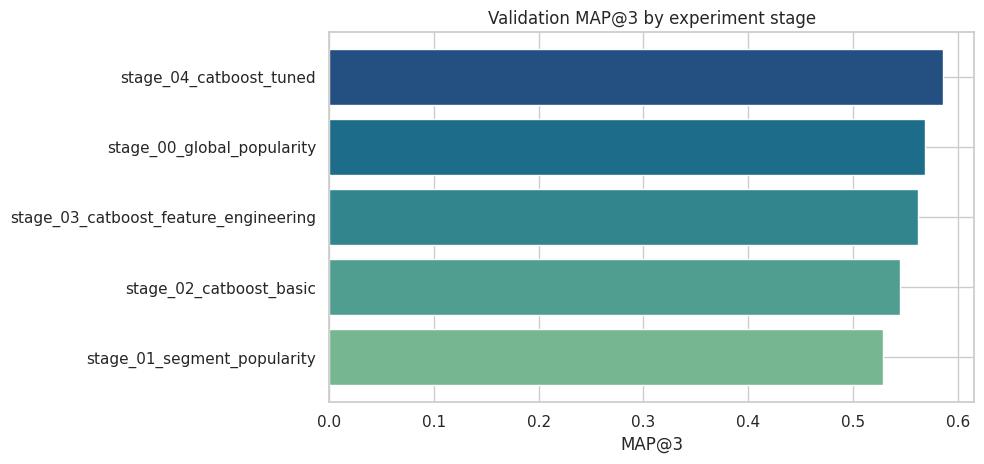

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = experiment_leaderboard.sort_values('val_map_at_3', ascending=True)
ax.barh(plot_df['stage_name'], plot_df['val_map_at_3'], color=sns.color_palette('crest', n_colors=len(plot_df)))
ax.set_title('Значение MAP@3 на validation по стадиям эксперимента')
ax.set_xlabel('MAP@3')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

На графике хорошо видна сама траектория улучшений. Segment baseline оказывается слабее глобального baseline, базовый CatBoost не сразу превосходит сильный popularity-ориентированный ориентир, а заметный рост начинается после сочетания feature engineering и новой tuning-stage. В результате финальная tuned-модель формирует наиболее высокий `MAP@3` среди всех рассмотренных подходов.


Новая tuning-stage дала измеримый эффект. Лучшая tuned-конфигурация улучшила validation `MAP@3` примерно на `+0.0239` относительно CatBoost после feature engineering и на `+0.0415` относительно базовой CatBoost-модели. На test прирост тоже сохранился: `0.6128` против `0.6019` у `stage_03` и `0.5709` у `stage_02`.

Следовательно, новая tuning-stage уменьшила вычислительную тяжесть поиска и одновременно дала прирост качества без перехода к большому brute-force search.


## 9. Что произошло на новой tuning-stage

Ниже отдельно показаны результаты двух этапов подбора.

- `Stage A` отвечает за дешёвый screening и быстро отбрасывает слабые конфигурации.
- `Stage B` нужен не для нового перебора, а для честного подтверждения только лучших кандидатов в более полном режиме.

In [13]:
stage_a_leaderboard

,candidate_id,candidate_name,search_stage,run_id,fit_rows,eval_rows,fit_seconds,val_map_at_3,val_precision_at_3,val_recall_at_3,...,iterations,depth,learning_rate,l2_leaf_reg,min_data_in_leaf,random_strength,bootstrap_type,bagging_temperature,subsample,screening_rank
0,5,stage_04a_candidate_05,stage_a,db972a310bb14b999c904b41b029fd0f,10000,2000,5.8500,0.5784,0.1427,0.6932,...,150,6,0.0900,7.0000,64,0.7000,Bayesian,0.2000,NaN,1
1,2,stage_04a_candidate_02,stage_a,b8fcc78338884aa7b5d7863f344bdb08,10000,2000,13.1000,0.5733,0.1428,0.6933,...,200,6,0.0600,5.0000,32,1.0000,Bayesian,0.5000,NaN,2
2,3,stage_04a_candidate_03,stage_a,593c7a30118b4f0aae0413c7efc2d3cb,10000,2000,15.1200,0.5669,0.1445,0.7025,...,240,6,0.0500,6.0000,48,1.2000,Bayesian,1.0000,NaN,3
3,1,stage_04a_candidate_01,stage_a,fe9d2349248147b4aadc9cbb1782c632,10000,2000,5.6400,0.5632,0.1388,0.6773,...,160,5,0.0800,4.0000,48,0.5000,Bayesian,0.0000,NaN,4
4,4,stage_04a_candidate_04,stage_a,224947ecf29a4f18b91eba1a381400dd,10000,2000,14.1500,0.5474,0.1355,0.6617,...,220,7,0.0500,5.0000,32,1.5000,Bernoulli,NaN,0.8000,5


Таблица Stage A показывает screening ручного search space. Лучший кандидат определяется не самым большим числом итераций и не самой глубокой моделью, а сочетанием умеренной сложности и более жёсткой регуляризации. Лидером стал `candidate_05` с `val_map_at_3 = 0.5784`; при этом он остаётся одним из самых быстрых по времени обучения.


In [14]:
stage_b_leaderboard

,candidate_id,candidate_name,search_stage,run_id,fit_rows,eval_rows,fit_seconds,val_map_at_3,val_precision_at_3,val_recall_at_3,val_ndcg_at_3,screening_rank,iterations,depth,learning_rate,l2_leaf_reg,min_data_in_leaf,random_strength,bootstrap_type,bagging_temperature
0,5,stage_04b_candidate_05,stage_b,bd9af47ef82b4559ae1118d95cbe2d46,33643,3000,24.1600,0.5862,0.1488,0.7207,0.6271,1,150,6,0.0900,7.0000,64,0.7000,Bayesian,0.2000


Stage B подтверждает результат Stage A на более полном train sample. В текущем запуске в финальное подтверждение прошёл один лучший кандидат, и его качество выросло с `0.5784` до `0.5862` по validation `MAP@3`. Быстрый screening и полный прогон указывают на одну и ту же конфигурацию, а итоговая оценка после подтверждения становится выше.


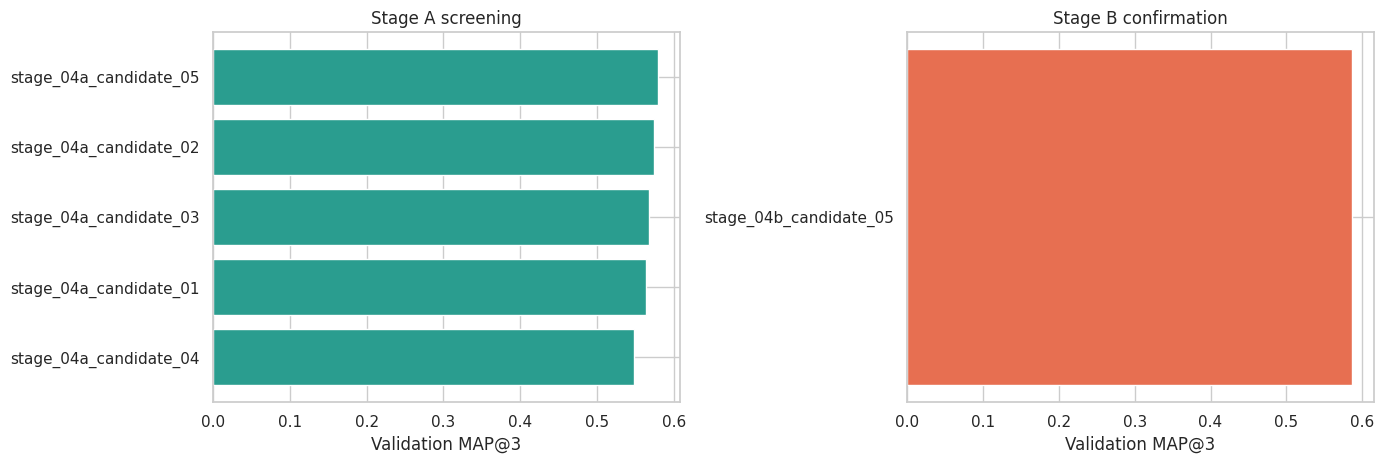

In [15]:
if not stage_a_leaderboard.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=False)

    stage_a_sorted = stage_a_leaderboard.sort_values('val_map_at_3', ascending=True)
    axes[0].barh(stage_a_sorted['candidate_name'], stage_a_sorted['val_map_at_3'], color='#2a9d8f')
    axes[0].set_title('Stage A: быстрый screening')
    axes[0].set_xlabel('MAP@3 на validation')
    axes[0].set_ylabel('')

    if not stage_b_leaderboard.empty:
        stage_b_sorted = stage_b_leaderboard.sort_values('val_map_at_3', ascending=True)
        axes[1].barh(stage_b_sorted['candidate_name'], stage_b_sorted['val_map_at_3'], color='#e76f51')
        axes[1].set_title('Stage B: финальное подтверждение')
        axes[1].set_xlabel('MAP@3 на validation')
        axes[1].set_ylabel('')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Парные графики читаются совместно. Левая часть показывает, насколько Stage A разделяет сильные и слабые конфигурации уже на дешёвом screening. Правая часть фиксирует итоговый выбор после подтверждения. В текущем эксперименте переход от Stage A к Stage B не меняет победителя, поэтому схема подбора работает стабильно и не зависит от случайного шума в preliminary-оценке.


Интерпретация этой части проста:

- если Stage A уже хорошо отделяет сильные конфигурации от слабых, значит screening действительно выполняет свою роль;
- если победитель Stage B совпадает с лидером или почти лидером Stage A, значит схема устойчива и не зависит от случайного шума;
- если лидер меняется, Stage B показывает, зачем нужен второй шаг на полном train sample.

## 10. Feature importance и интерпретация модели

Ниже агрегируются важности признаков по продуктовым one-vs-rest моделям. Такая агрегация показывает признаки, которые стабильно влияют на вероятность нового подключения сразу в нескольких продуктовых задачах.


In [16]:
best_bundle = joblib.load(MODELS_DIR / 'best_model.joblib')
selected_stage = best_bundle['selected_model']
feature_importance = pd.read_csv(MODELS_DIR / f'{selected_stage}_feature_importance.csv')

aggregated_importance = (
    feature_importance.groupby('feature_name', as_index=False)
    .agg(mean_importance=('importance', 'mean'), covered_products=('product', 'nunique'))
    .sort_values('mean_importance', ascending=False)
)
aggregated_importance.head(15)

,feature_name,mean_importance,covered_products
0,age,12.4556,22
1,antiguedad,9.7608,22
11,ind_cno_fin_ult1,8.4527,16
5,customer_since_months,7.9574,22
35,products_dropped_prev_month,6.5879,21
37,renta,5.7666,22
2,canal_entrada,4.9126,9
41,tiprel_1mes,4.8185,21
39,sexo,4.7972,16
36,products_total,4.7281,21


Таблица агрегированных importance показывает признаки, которые остаются значимыми сразу для нескольких продуктовых моделей. Признаки с высокой средней важностью и большим покрытием по продуктам задают общую логику ранжирования в системе рекомендаций.


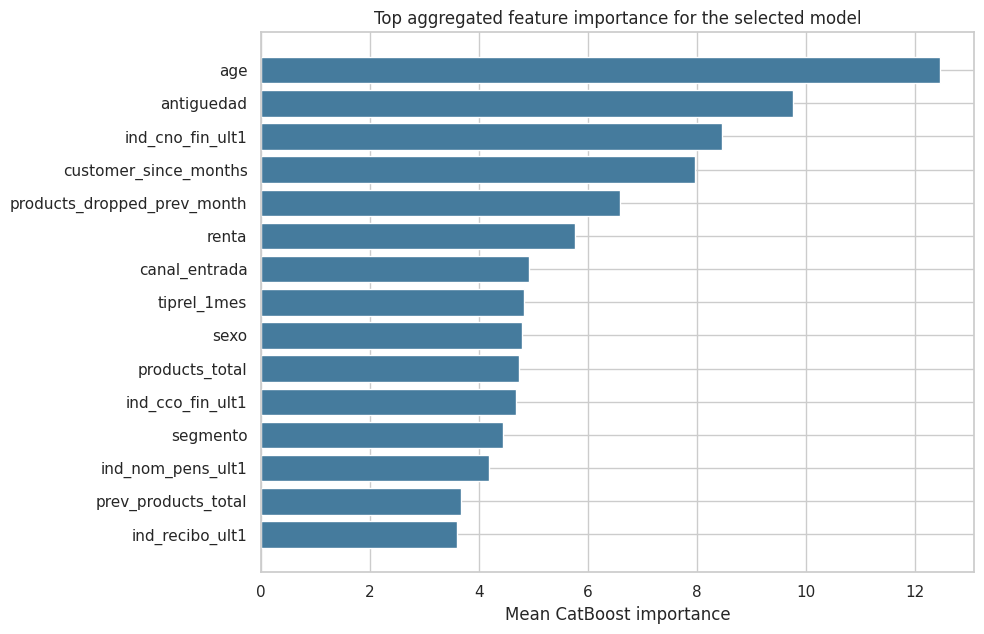

In [17]:
fig, ax = plt.subplots(figsize=(10, 6.5))
plot_importance = aggregated_importance.head(15).sort_values('mean_importance', ascending=True)
ax.barh(plot_importance['feature_name'], plot_importance['mean_importance'], color='#457b9d')
ax.set_title('Наиболее важные признаки выбранной модели')
ax.set_xlabel('Средняя важность признака в CatBoost')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

График показывает доминирующие сигналы модели. В верхней части обычно оказываются признаки, связанные с текущим портфелем, его недавней динамикой и базовым клиентским контекстом. Вероятность нового подключения определяется сочетанием состояния клиента и недавних изменений его продуктовой истории, а не одним статическим атрибутом.


Среди наиболее значимых признаков выделяются две группы:

- состояние текущего портфеля и его недавние изменения;
- клиентский контекст: сегмент, канал входа, активность, стаж, доход.

Модель ранжирует предложения для клиента с уже сложившимся профилем и текущим набором продуктов, поэтому обе группы сигналов оказываются естественными для recommendation-задачи.


## 11. Анализ качества по продуктам

Общая `MAP@3` используется для выбора модели, а таблица ниже показывает качество в разрезе продуктов. Для каждого продукта считается, как часто модель попадала в top-3 там, где этот продукт действительно появился.


In [18]:
test_frames = load_sampled_evaluation_frames(
    config,
    config.test_months,
    sample_size=min(config.eval_month_sample_size, 20000),
    seed=config.random_state + 777,
)
test_df = pd.concat([frame for _, frame in test_frames], ignore_index=True)
scores = score_dataframe(best_bundle, test_df)
recommendations = build_recommendation_indices(scores, test_df[PRODUCT_COLUMNS].to_numpy(), k=config.top_k)
y_true = test_df[[f'target__{product}' for product in PRODUCT_COLUMNS]].to_numpy()

product_rows = []
for product_idx, product in enumerate(PRODUCT_COLUMNS):
    product_events = int(y_true[:, product_idx].sum())
    product_hits = int(sum(int(product_idx in row[:config.top_k]) and y_true[row_idx, product_idx] == 1 for row_idx, row in enumerate(recommendations)))
    recommended_count = int((recommendations[:, :config.top_k] == product_idx).sum())
    product_rows.append(
        {
            'product_code': product,
            'product_name': PRODUCT_NAME_MAP[product],
            'true_events': product_events,
            'top3_hits': product_hits,
            'hit_rate_at_3': product_hits / product_events if product_events else 0.0,
            'recommended_count': recommended_count,
        }
    )

product_quality = pd.DataFrame(product_rows).sort_values(['hit_rate_at_3', 'true_events'], ascending=[False, False])
product_quality.head(12)

,product_code,product_name,true_events,top3_hits,hit_rate_at_3,recommended_count
5,ind_ctju_fin_ult1,Junior account,26,26,1.0000,50
6,ind_ctma_fin_ult1,More particular account,417,364,0.8729,3247
2,ind_cco_fin_ult1,Current accounts,2938,2553,0.8690,11238
23,ind_recibo_ult1,Direct debit,7307,5985,0.8191,12944
18,ind_tjcr_fin_ult1,Credit card,3038,2372,0.7808,7964
21,ind_nomina_ult1,Payroll,3398,2648,0.7793,11302
22,ind_nom_pens_ult1,Pensions payroll,3633,2795,0.7693,9014
4,ind_cno_fin_ult1,Payroll account,1699,1304,0.7675,12133
7,ind_ctop_fin_ult1,Particular account,169,124,0.7337,7009
11,ind_dela_fin_ult1,Long-term deposits,67,48,0.7164,12692


Эта таблица показывает качество модели в разрезе продуктов. По ней видно, где модель уверенно попадает в top-3, а где качество ограничивается редкостью события. Общая `MAP@3` усредняет результат, а per-product метрики раскрывают различия между отдельными продуктовыми направлениями.


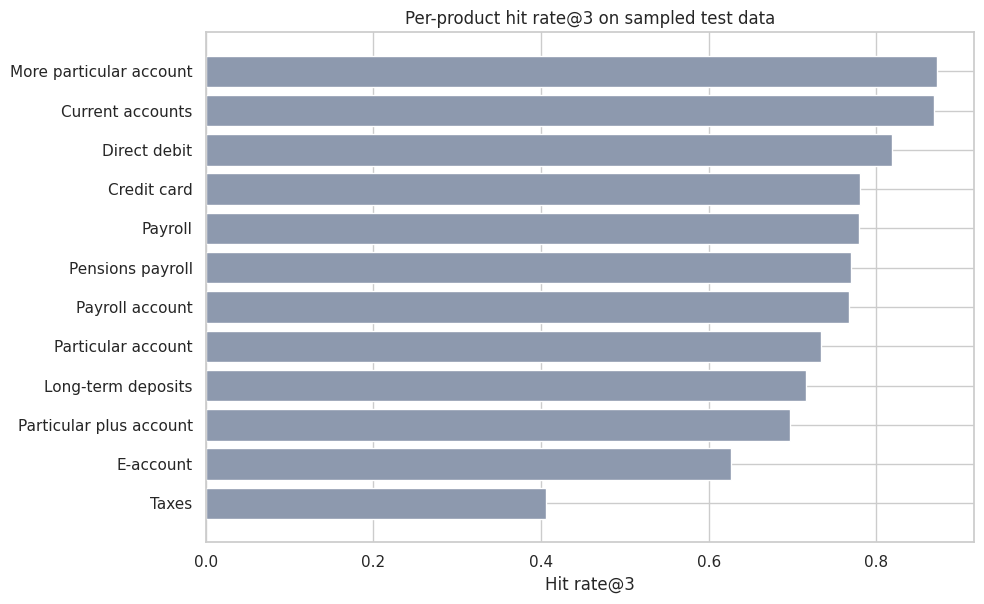

In [19]:
plot_product_quality = product_quality.loc[product_quality['true_events'] >= 30].head(12).sort_values('hit_rate_at_3', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6.2))
ax.barh(plot_product_quality['product_name'], plot_product_quality['hit_rate_at_3'], color='#8d99ae')
ax.set_title('Hit rate@3 по продуктам на sampled test')
ax.set_xlabel('Hit rate@3')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

На графике различия между продуктами становятся визуально очевидными. Более массовые продукты обычно имеют более высокий hit rate@3, потому что по ним в данных сильнее обучающий сигнал. Продукты с низким hit rate часто оказываются либо редкими, либо более сложными для предсказания, и именно они формируют основную зону дальнейших улучшений модели.


Per-product разрез показывает три свойства.

- массовые продукты обычно легче подхватываются моделью из-за более сильного сигнала;
- редкие продукты чаще оказываются «трудными» и формируют основную часть ошибок;
- per-product анализ дополняет общую `MAP@3`, но не заменяет её как главную метрику выбора конфигурации.


## 12. Распределение score и error analysis

Раздел ниже показывает две стороны поведения модели:

- распределение top-score в ранжировании;
- реальные случаи ошибок на уровне клиентов и продуктов.


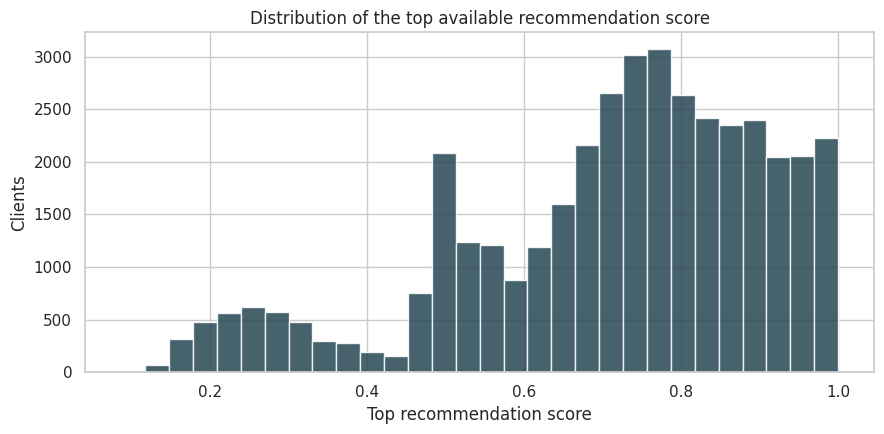

In [20]:
masked_scores = scores.copy()
masked_scores[test_df[PRODUCT_COLUMNS].to_numpy() == 1] = -1.0
top_scores = np.max(masked_scores, axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(top_scores[top_scores > -1], bins=30, color='#264653', alpha=0.85)
ax.set_title('Распределение максимального доступного recommendation score')
ax.set_xlabel('Максимальный recommendation score')
ax.set_ylabel('Клиенты')
plt.tight_layout()
plt.show()

Распределение top-score показывает, насколько уверенно модель отделяет сильные кандидаты от слабых. Если заметная часть наблюдений сосредоточена в зоне умеренных и высоких score, ranking не вырождается в почти случайный выбор. Хвост распределения показывает клиентов, для которых модель остаётся менее уверенной.


In [21]:
validation_errors_path = MODELS_DIR / f'{selected_stage}_validation_errors.csv'
validation_errors = pd.read_csv(validation_errors_path) if validation_errors_path.exists() else pd.DataFrame()
validation_errors.head(10)

,fecha_dato,target_month,ncodpers,segmento,products_total,true_products,recommended_products,missed_products,split_name,snapshot_month
0,2015-11-28 00:00:00,2015-12-28 00:00:00,909594,02 - PARTICULARES,2.0000,['ind_cno_fin_ult1'],"['ind_dela_fin_ult1', 'ind_tjcr_fin_ult1', 'ind_fond_fin_ult1']",['ind_cno_fin_ult1'],valid,2015-11-28
1,2015-11-28 00:00:00,2015-12-28 00:00:00,1204072,02 - PARTICULARES,1.0000,['ind_cco_fin_ult1'],"['ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1']",['ind_cco_fin_ult1'],valid,2015-11-28
2,2015-11-28 00:00:00,2015-12-28 00:00:00,1493952,02 - PARTICULARES,1.0000,"['ind_fond_fin_ult1', 'ind_valo_fin_ult1']","['ind_ctma_fin_ult1', 'ind_deco_fin_ult1', 'ind_dela_fin_ult1']","['ind_fond_fin_ult1', 'ind_valo_fin_ult1']",valid,2015-11-28
3,2015-11-28 00:00:00,2015-12-28 00:00:00,1497730,UNKNOWN,1.0000,"['ind_cno_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1']","['ind_deco_fin_ult1', 'ind_ctma_fin_ult1', 'ind_fond_fin_ult1']","['ind_cno_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1']",valid,2015-11-28
4,2015-11-28 00:00:00,2015-12-28 00:00:00,873770,03 - UNIVERSITARIO,4.0000,"['ind_ecue_fin_ult1', 'ind_tjcr_fin_ult1']","['ind_ctpp_fin_ult1', 'ind_ecue_fin_ult1', 'ind_cco_fin_ult1']",['ind_tjcr_fin_ult1'],valid,2015-11-28
5,2015-11-28 00:00:00,2015-12-28 00:00:00,160481,01 - TOP,1.0000,['ind_cno_fin_ult1'],"['ind_dela_fin_ult1', 'ind_ecue_fin_ult1', 'ind_fond_fin_ult1']",['ind_cno_fin_ult1'],valid,2015-11-28
6,2015-11-28 00:00:00,2015-12-28 00:00:00,364222,02 - PARTICULARES,2.0000,"['ind_nomina_ult1', 'ind_nom_pens_ult1']","['ind_ctpp_fin_ult1', 'ind_dela_fin_ult1', 'ind_fond_fin_ult1']","['ind_nomina_ult1', 'ind_nom_pens_ult1']",valid,2015-11-28
7,2015-11-28 00:00:00,2015-12-28 00:00:00,57002,02 - PARTICULARES,3.0000,"['ind_cno_fin_ult1', 'ind_recibo_ult1']","['ind_recibo_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1']",['ind_cno_fin_ult1'],valid,2015-11-28
8,2015-11-28 00:00:00,2015-12-28 00:00:00,413106,02 - PARTICULARES,1.0000,['ind_nom_pens_ult1'],"['ind_ctma_fin_ult1', 'ind_dela_fin_ult1', 'ind_deco_fin_ult1']",['ind_nom_pens_ult1'],valid,2015-11-28
9,2015-11-28 00:00:00,2015-12-28 00:00:00,218026,02 - PARTICULARES,5.0000,['ind_cco_fin_ult1'],"['ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_ctpp_fin_ult1']",['ind_cco_fin_ult1'],valid,2015-11-28


Таблица ошибок переводит агрегированные метрики в конкретные случаи. В ней видно, какие истинные подключения чаще всего оказываются в `missed_products`, какие продукты модель рекомендовала вместо них и есть ли у таких примеров общий профиль по сегменту или насыщенности портфеля. Эти наблюдения задают направления для следующей итерации feature engineering.


По таблице ошибок можно отдельно смотреть:

- какие продукты чаще всего попадают в `missed_products`;
- есть ли у ошибок общий профиль клиента или сегмента.

Эти закономерности связывают quality metrics с конкретными типами промахов модели.


## 13. Связь с MLflow и итоговый выбор модели

Новая схема отбора специально синхронизирована с MLflow:

- каждый tuning-кандидат логируется как отдельный run;
- у всех runs используется единая главная метрика `val_map_at_3`;
- финальная tuned-модель отдельно сохраняется как полноценный stage-run;
- выбранный CatBoost-run регистрируется в MLflow Model Registry.

In [22]:
selected_stage = metadata['selected_model']
selected_stage_payload = metadata['stages'][selected_stage]

pd.DataFrame(
    {
        'selected_stage': [selected_stage],
        'primary_metric_name': [metadata['primary_metric_name']],
        'validation_metric_value': [selected_stage_payload['valid'][f'map_at_{config.top_k}']],
        'registered_model_name': [metadata['registered_model_name']],
        'registry_alias': [metadata['registered_model_alias']],
        'registry_version': [selected_stage_payload.get('registry_version')],
        'run_id': [selected_stage_payload.get('run_id')],
    }
)

,selected_stage,primary_metric_name,validation_metric_value,registered_model_name,registry_alias,registry_version,run_id
0,stage_04_catboost_tuned,val_map_at_3,0.5862,bank-product-recommendations-catboost,champion,3,ace89cc484ce4f39921ddcb5d4a5149c


Финальная таблица фиксирует связь между экспериментом и production-артефактом. Она показывает, какая стадия выбрана победителем, по какой метрике принималось решение, какой у неё run_id и под какой версией модель зарегистрирована в MLflow Model Registry. Благодаря этому итоговый выбор полностью прослеживается от офлайн-эксперимента до зарегистрированной модели.


## 14. Вывод

Итоговая картина проекта получилась внутренне согласованной.

Во-первых, задача корректно поставлена как recommendation / ranking по новым продуктам следующего месяца. Target строится как переход `t -> t+1`, а уже имеющиеся продукты исключаются из рекомендаций. Такая схема делает offline-оценку согласованной с реальным сценарием использования модели.

Во-вторых, последовательность экспериментов показывает понятную траекторию улучшений. Глобальный popularity baseline дал `val_map_at_3 = 0.5686`, сегментный baseline — `0.5283`, базовый CatBoost — `0.5446`, CatBoost с feature engineering — `0.5623`, а финальный tuned CatBoost — `0.5862`. На test лучшая модель тоже сохранила лидерство с `test_map_at_3 = 0.6128`, поэтому выигрыш не остался только на validation.

В-третьих, новая tuning-stage дала эффект и по устойчивости, и по качеству. В `Stage A` было проверено 5 компактных конфигураций на ограниченном train sample. Лучшей стала конфигурация `candidate_05` с `iterations=150`, `depth=6`, `learning_rate=0.09`, `l2_leaf_reg=7.0`, `min_data_in_leaf=64`, `random_strength=0.7` и `bagging_temperature=0.2`, показавшая `val_map_at_3 = 0.5784` уже на быстром screening. Затем в `Stage B` эта же конфигурация была подтверждена на более полном train sample и улучшилась до `val_map_at_3 = 0.5862`.

Наконец, итоговый пайплайн работает в более практичном режиме. Обучение идёт с фиксированным time-based `eval_set`, `early_stopping`, ограничением `thread_count`, небольшим ручным search space и cap на полный train sample, что снижает риск memory-related crash. Все candidate runs логируются в MLflow, а итоговая модель регистрируется в Model Registry.
